In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Conditional Generation

The generator of that section accepts noise but offers no control over the sample it returns. Many applications instead request an image from a specified class, an image matching a caption, or a restoration consistent with a corrupted input. Conditional generation supplies this control by giving the condition to both the generator and the critic. This section first derives the conditional game, which applies the analysis of that section separately within each condition. It then compares mechanisms for introducing the condition into the networks and derives the projection discriminator from the optimal conditional critic. Finally, it evaluates whether a class-conditional CIFAR-10 generator obeys its requested labels without sacrificing sample quality or diversity. The section concludes by relating class conditioning to paired and unpaired image translation.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import numpy as np
import pickle
import torch
import warnings
from torch import nn
from torch.nn import functional as F

## The Conditional Game

A condition specifies a property of the requested sample. It may be a class label, a caption embedding, or an entire image. Our running example uses the ten CIFAR-10 class labels. The data consists of image--label pairs drawn from a joint distribution $p(x,c)$. The generator also receives the condition, so $x' = G(z,c)$ and varying $z$ at fixed $c$ samples from a conditional distribution $q(\cdot \mid c)$. We draw generator conditions from the data marginal $p(c)$. The generated pairs then follow $q(x,c)=p(c)\,q(x\mid c)$. Thus the real and generated joint distributions have the same condition marginal and differ only in their conditional image distributions.

The critic scores sample--condition pairs, $D(x, c)$, and the game is the log-loss game of that section played on those pairs:

$$
V(D) \;=\; E_{(x, c) \sim p}\big[\log \sigma(D(x, c))\big]
+ E_{c \sim p(c),\; x' \sim q(\cdot \mid c)}\big[\log \sigma(-D(x', c))\big].
$$

The pointwise argument for the original game applies to any classifier input space. Replacing the sample $x$ by the pair $(x, c)$ makes the optimal critic of the equation the log ratio of the two joint densities. Their shared condition marginal cancels:

$$
D^\star(x, c)
\;=\; \log \frac{p(x, c)}{q(x, c)}
\;=\; \log \frac{p(c)\, p(x \mid c)}{p(c)\, q(x \mid c)}
\;=\; \log \frac{p(x \mid c)}{q(x \mid c)} .
$$

The optimal conditional critic is the log density ratio $\lambda$ within the subset selected by the condition. For CIFAR-10, the score for the bird condition compares real and generated birds; samples from other classes do not contribute. Substituting this best response into the equation retains the outer expectation over $c$. Each condition contributes the value that the equation assigns to its two conditional distributions:

$$
\max_D V(D)
\;=\; E_{c}\Big[\, 2\, \mathrm{JS}\big(p(\cdot \mid c),\, q(\cdot \mid c)\big) \Big] - 2 \log 2 .
$$

The conditional game is an average of per-condition games, weighted by how often each condition occurs. Its value reaches the minimum $-2\log 2$ exactly when $q(\cdot \mid c) = p(\cdot \mid c)$ for every condition that $p(c)$ weights: the generator must match the data within every slice.

This requirement is stronger than matching the unconditional distribution. Consider a generator that produces accurate CIFAR-10 images but shifts every label cyclically, so that $q(\cdot \mid c) = p(\cdot \mid c{+}1)$. A request for a bird then produces a cat. Because all ten classes occur equally often, the cyclic shift leaves the mixture over classes unchanged. The unconditional generator distribution equals the data marginal, so the game in that section cannot detect the incorrect labels. By contrast, the equation averages divergences between the mismatched class-conditional distributions and is far from its minimum. Exercise 2 verifies this decomposition on a toy example with known densities.

Equations the equation and the equation apply the chapter's unconditional identities separately to each condition. Saturation on disjoint supports, the non-saturating weight in the equation, the pairing objective from that section, and the zero-centered penalties from that section therefore extend in the same way. Conditioning changes the network inputs and the data pipeline, but not these arguments.

The weighting by $p(c)$ has two consequences for imbalanced data. First, a rare condition contributes little to the objective, so the generator can perform poorly on it at a small cost. Second, the cancellation in the equation assumes that generator conditions are sampled from the data marginal. If the sampling distribution $r(c)$ differs from $p(c)$, the optimal critic gains the offset $\log(p(c)/r(c))$. Reweighting or resampling the real batches to match $r(c)$ removes this offset, as in class-balanced training. Exercise 3 examines both effects.

## How the Condition Enters the Networks

The analysis specifies the function computed by an optimal critic but not how a network should represent $c$. Three common mechanisms are concatenation, condition-dependent modulation of intermediate activations, and a critic head that scores compatibility between the sample and condition. They differ in the structural assumptions built into the network.

The first mechanism is *concatenation* [@Mirza.Osindero.2014]. The condition is embedded in a vector and appended to an existing input pathway: beside the latent code in the generator, or beside the image or an intermediate feature map in the critic. Concatenation works for discrete and continuous conditions and imposes little structure on their interaction with the sample. Consequently, the network must learn that interaction from the adversarial signal alone.

The second mechanism uses the condition to control intermediate activations. After normalizing a feature map $h$, learned functions of the condition supply the affine coefficients in $h \mapsto \gamma(c) \cdot \mathrm{norm}(h) + \beta(c)$. Conditional batch normalization, FiLM, and AdaIN are instances of this *condition-dependent modulation*. They differ in the normalization rule and in the functions used to compute $\gamma$ and $\beta$. SPADE is a spatial variant in which a semantic layout supplies a separate scale and offset at each location [@Park.Liu.Wang.ea.2019]. Applying modulation at several layers gives the condition a direct influence on global attributes such as class or style. The R3GAN supplement omits normalization-based conditioning to keep the architecture minimal, while reporting that it improves FID [@Huang.Gokaslan.Kuleshov.ea.2024].

The third mechanism conditions the critic through a *compatibility head*. Its most common form follows from the optimal critic in the equation. Bayes' rule gives $p(x \mid c) = p(c \mid x)\, p(x) / p(c)$. Applying this identity to the numerator and denominator cancels the shared label marginal and yields

$$
\log \frac{p(x \mid c)}{q(x \mid c)}
\;=\; \log \frac{p(c \mid x)}{q(c \mid x)} + \log \frac{p(x)}{q(x)} .
$$

The optimal conditional critic thus separates unconditional sample quality from condition compatibility. The second term is the unconditional log density ratio $\lambda$ from that section. The first compares the real and generated *label posteriors* for the pair $(x,c)$. A generator that produces realistic images with scrambled labels differs from the data through the first term. A generator that produces poorly formed images of the requested class differs through the second.

The first term has a form every classifier in this book has used. Model both posteriors as softmax classifiers over one shared feature map $\varphi$, so that $p(c \mid x) \propto \exp(u_c^\top \varphi(x))$ with one weight vector per class, and $q(c \mid x) \propto \exp(w_c^\top \varphi(x))$ likewise. The two normalizers do not depend on $c$, so the log ratio of the posteriors is the inner product $(u_c - w_c)^\top \varphi(x)$ plus a function of $x$ alone. Absorbing that function, together with the unconditional term of the equation, into a single head $\psi$, and writing $e_c = u_c - w_c$, the critic becomes

$$
D(x, c) \;=\; e_c^\top \varphi(x) + \psi(x) :
$$

This expression contains one learned embedding per class, an inner product with the critic features, and an unconditional head. It is the *projection discriminator* of @Miyato.Koyama.2018 . The bilinear term makes the score depend on the compatibility of the sample and condition. Thus the architecture represents the decomposition in the equation directly rather than learning it through unrestricted concatenation. Bayes' rule gives an identity, but the log-linear form of both posteriors in a *shared* feature map is a modeling assumption. Learning $\varphi$ makes this restriction more flexible, though one representation must still support both posteriors. Exercise 1 examines the effect of limited capacity. Projection heads are standard in large class-conditional GANs; BigGAN uses one for ImageNet [@Brock.Donahue.Simonyan.2019].

The projection head is not the only compatibility mechanism. The *auxiliary classifier* of @Odena.Olah.Shlens.2017 adds a classification head and loss to the critic. The critic predicts the condition from its features, and the generator is trained to make its samples receive the requested label. This objective may favor exaggerated class prototypes and reduce within-class diversity, because such samples are easy for the classifier to label. The generator also optimizes the same quantity later used to measure condition alignment, which can make that metric misleading. Text and other structured conditions are commonly incorporated through cross-attention from condition tokens to image features, as in the text-to-image GAN of @Kang.Zhu.Zhang.ea.2023 . By 2026, diffusion and autoregressive models dominate general text-to-image synthesis; adversarial variants remain useful when single-pass sampling speed is important.

The experiment uses concatenation in the generator and a projection head in the critic. No corresponding identity determines how the generator should transform $c$, so concatenation leaves this interaction flexible. Equation the equation provides a direct structural motivation for the critic's projection head. R3GAN uses the same division in its class-conditional experiments [@Huang.Gokaslan.Kuleshov.ea.2024]. Exercise 6 replaces the projection head with concatenation and compares the two critics at the same budget.

## Class-Conditional CIFAR-10

We evaluate the method on CIFAR-10, which contains 50,000 labeled $32 \times 32$ training images from ten classes. that section used these images to train a feature network; here they are the target distribution. R3GAN also reports a class-conditional CIFAR-10 benchmark, trained for four days on eight GPUs [@Huang.Gokaslan.Kuleshov.ea.2024]. Our run uses 15,000 steps and completes in well under half an hour on one GPU. Its purpose is to test the conditioning mechanism rather than to match large-scale sample quality. The data registration is repeated because each section executes as an independent notebook.

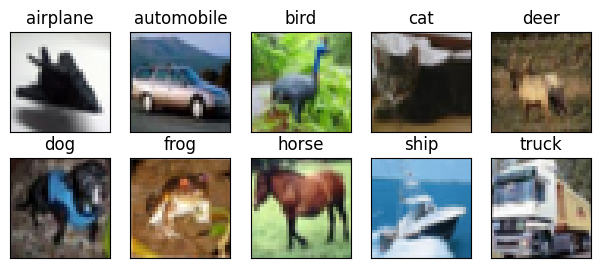

In [2]:
d2l.DATA_HUB['cifar10'] = (
    'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
    '874905e36347c8536514d0a26261acf3bff89bc7')
cifar_dir = d2l.download_extract('cifar10', 'cifar-10-batches-py')
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

def load_cifar_batch(path):
    with open(path, 'rb') as f, warnings.catch_warnings():
        warnings.simplefilter('ignore')   # legacy NumPy pickle format
        batch = pickle.load(f, encoding='bytes')
    X = torch.tensor(batch[b'data'], dtype=torch.float32)
    return X.reshape(-1, 3, 32, 32) / 127.5 - 1, torch.tensor(
        batch[b'labels'])

Xs, ys = zip(*[load_cifar_batch(f'{cifar_dir}/data_batch_{i}')
               for i in range(1, 6)])
device = d2l.try_gpu()
train_X, train_y = torch.cat(Xs).to(device), torch.cat(ys).to(device)
test_X, test_y = load_cifar_batch(f'{cifar_dir}/test_batch')
test_X, test_y = test_X.to(device), test_y.to(device)
first = [int((train_y == c).nonzero()[0]) for c in range(10)]
d2l.show_images(train_X[first].cpu().permute(0, 2, 3, 1) / 2 + 0.5,
                num_rows=2, num_cols=5, titles=classes);

### A Conditional Backbone

The networks use the minimal modern backbone from that section, with one resolution stage removed for the smaller images. Both networks receive the condition. The generator retains its learned $4 \times 4$ constant and projected latent code. It broadcasts a class embedding over the $4 \times 4$ grid and concatenates all three tensors. A mixing convolution combines the constant, latent code, and condition before the upsampling stages increase the resolution from $4$ to $8$, $16$, and $32$. As in that section, the network uses bilinear resampling, leaky ReLU, no normalization, and no tanh output.

In [3]:
class Generator(nn.Module):
    """Learned 4x4 constant + projected latent + class embedding."""
    def __init__(self, latent_dim=100, embed_dim=64, const_ch=128,
                 base_ch=256, num_classes=10):
        super().__init__()
        self.latent_dim, self.embed_dim = latent_dim, embed_dim
        self.const = nn.Parameter(0.02 * torch.randn(1, const_ch, 4, 4))
        self.z_proj = nn.Linear(latent_dim, 16 * latent_dim)
        self.embed = nn.Embedding(num_classes, embed_dim)
        self.mix = nn.Conv2d(const_ch + latent_dim + embed_dim, base_ch,
                             3, padding=1)
        chans = [base_ch // 2 ** i for i in range(4)]    # 256, 128, 64, 32
        self.stages = nn.ModuleList(
            [nn.Conv2d(c_in, c_out, 3, padding=1)
             for c_in, c_out in zip(chans[:-1], chans[1:])])
        self.to_rgb = nn.Conv2d(chans[-1], 3, 3, padding=1)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, z, y):
        zc = self.z_proj(z).reshape(-1, self.latent_dim, 4, 4)
        ec = self.embed(y)[:, :, None, None].expand(-1, -1, 4, 4)
        const = self.const.expand(z.shape[0], -1, -1, -1)
        x = self.act(self.mix(torch.cat([const, zc, ec], dim=1)))
        for conv in self.stages:                     # 4 -> 8 -> 16 -> 32
            x = F.interpolate(x, scale_factor=2, mode='bilinear')
            x = self.act(conv(x))
        return self.to_rgb(x)

The critic mirrors the generator down to $4 \times 4$ and then implements the equation. Summing the final feature map over spatial positions gives $\varphi(x)$. A table contains one embedding $e_c$ for each class, and a linear head on $\varphi(x)$ represents $\psi(x)$. The score adds $\psi(x)$ to the inner product $e_c^\top\varphi(x)$. The derivation permits $\psi$ to be any function of $x$; following @Miyato.Koyama.2018, the implementation restricts it to a linear function of the shared features.

In [4]:
class Discriminator(nn.Module):
    """Mirror backbone with a projection head: psi(x) + e_c . phi(x)."""
    def __init__(self, base_ch=64, num_classes=10):
        super().__init__()
        chans = [3] + [base_ch * 2 ** i for i in range(3)]  # 3, 64, ..., 256
        self.stages = nn.ModuleList(
            [nn.Conv2d(c_in, c_out, 3, padding=1)
             for c_in, c_out in zip(chans[:-1], chans[1:])])
        self.mix = nn.Conv2d(chans[-1], 2 * chans[-1], 3, padding=1)
        self.psi = nn.Linear(2 * chans[-1], 1)
        self.embed = nn.Embedding(num_classes, 2 * chans[-1])
        self.act = nn.LeakyReLU(0.2)

    def phi(self, x):
        for conv in self.stages:                     # 32 -> 16 -> 8 -> 4
            x = F.interpolate(self.act(conv(x)), scale_factor=0.5,
                              mode='bilinear', antialias=True)
        return self.act(self.mix(x)).sum(dim=(2, 3))

    def forward(self, x, y):
        phi = self.phi(x)
        return self.psi(phi).squeeze(-1) + (self.embed(y) * phi).sum(dim=1)

net_G, net_D = Generator(), Discriminator()
print(net_G(torch.zeros(2, 100), torch.zeros(2, dtype=torch.long)).shape)
print(net_D(torch.zeros(2, 3, 32, 32),
            torch.zeros(2, dtype=torch.long)).shape)

torch.Size([2, 3, 32, 32])
torch.Size([2])


### Training with the Chapter's Loss

Training uses the relativistic pairing losses `d2l.rpgan_loss_D` and `d2l.rpgan_loss_G` from that section, together with both zero-centered penalties from `d2l.r1_r2_penalty`. In the conditional setting, each real--generated pair must share a condition. Comparing a real bird with a generated truck would not estimate the within-condition objective in the equation. We therefore draw a labeled real batch and use the same labels to condition the generated batch. The remaining training choices follow that section: horizontal flips augment the real images while preserving their labels, and a 500-step exponential moving average supplies the generator used for evaluation.

In [5]:
class EMA:
    """Exponential moving average of model weights, given as a half-life."""
    def __init__(self, model, half_life):
        self.shadow = {k: v.detach().clone()
                       for k, v in model.state_dict().items()}
        self.decay = 0.5 ** (1 / half_life)

    def update(self, model):
        with torch.no_grad():
            for k, v in model.state_dict().items():
                self.shadow[k].lerp_(v, 1 - self.decay)

    def copy_to(self, model):
        model.load_state_dict(self.shadow)

def sample_real(images, labels, n):
    """Draw a labeled training batch with random horizontal flips."""
    idx = torch.randint(0, len(images), (n,), device=images.device)
    batch = images[idx]
    flip = torch.rand(n, device=images.device) < 0.5
    return torch.where(flip.view(-1, 1, 1, 1), batch.flip(-1),
                       batch), labels[idx]

The library losses expect a critic that maps a batch of images to a batch of scores. Fixing the labels turns the conditional critic into such a function. In PyTorch, a lambda closes over the labels for both the pairing losses and the penalty. The JAX penalty helper differentiates each sample under `vmap`, so its closure must receive the corresponding label as well. The conditional helper below differs from `d2l.r1_r2_penalty` only by this additional argument. The training function returns the EMA generator and the trained critic for the subsequent diagnostics.

In [6]:
def train_conditional(train_X, train_y, gamma, num_steps=15000,
                      batch_size=128, lr=0.0002, latent_dim=100,
                      half_life=500, log_every=250, seed=0):
    torch.manual_seed(seed)
    net_G, net_D = Generator().to(device), Discriminator().to(device)
    def init_weights(module):
        if isinstance(module, (nn.Conv2d, nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, 0, 0.02)
            if getattr(module, 'bias', None) is not None:
                nn.init.zeros_(module.bias)
    for net in (net_G, net_D):
        net.apply(init_weights)
    trainer_G = torch.optim.Adam(net_G.parameters(), lr=lr,
                                 betas=(0.0, 0.99))
    trainer_D = torch.optim.Adam(net_D.parameters(), lr=lr,
                                 betas=(0.0, 0.99))
    ema, history = EMA(net_G, half_life), []
    for step in range(1, num_steps + 1):
        X, y = sample_real(train_X, train_y, batch_size)
        Z = torch.randn(batch_size, latent_dim, device=device)
        crit = lambda x: net_D(x, y)
        fake = net_G(Z, y).detach()
        r1, r2 = d2l.r1_r2_penalty(crit, X, fake)
        loss_D = (d2l.rpgan_loss_D(crit, X, fake)
                  + gamma / 2 * (r1 + r2).mean())
        trainer_D.zero_grad(), loss_D.backward(), trainer_D.step()
        X2, y2 = sample_real(train_X, train_y, batch_size)
        Z2 = torch.randn(batch_size, latent_dim, device=device)
        crit2 = lambda x: net_D(x, y2)
        loss_G = d2l.rpgan_loss_G(crit2, X2, net_G(Z2, y2))
        trainer_G.zero_grad(), loss_G.backward(), trainer_G.step()
        ema.update(net_G)
        if step % log_every == 0:
            with torch.no_grad():
                Xd, yd = sample_real(train_X, train_y, 256)
                d_real = net_D(Xd, yd).mean()
            history.append((step, float(loss_D.detach()),
                            float(loss_G.detach()),
                            float((r1 + r2).mean().detach()),
                            float(d_real)))
    ema_G = Generator().to(device)
    ema.copy_to(ema_G)
    return ema_G, net_D, torch.tensor(history)

We retune the penalty weight rather than reuse the value from the sprite experiment. A development-time pilot, not reproduced in this notebook, compared $\gamma \in \{0.05, 0.5, 5\}$ over 4,000 steps. All three values trained stably and reached similar condition alignment. They differed in the penalized quantity $E_m[\|\nabla_x D\|^2]$, as the equation predicts. At $\gamma = 0.05$, this quantity was several times larger than at $\gamma = 0.5$; at $\gamma = 5$, it remained near zero. These settings correspond to lighter and heavier damping, respectively. The full runs use the intermediate value $\gamma = 0.5$.

Penalty weights do not transfer unchanged between experiments. that section uses $\gamma = 10$ for $64 \times 64$ sprites, whereas R3GAN decays its tuned CIFAR-10 value from $0.05$ to $0.005$ during a four-day run [@Huang.Gokaslan.Kuleshov.ea.2024]. The appropriate value depends on the dataset, resolution, input scale, loss reduction, critic architecture, optimizer, batch size, augmentation, and training budget. A new implementation therefore requires its own sweep.

In [7]:
ema_G, net_D, history = train_conditional(train_X, train_y, gamma=0.5)
print(f'final loss_D {history[-1, 1]:.3f}, loss_G {history[-1, 2]:.3f}, '
      f'R1+R2 {history[-1, 3]:.3f}')

final loss_D 0.558, loss_G 0.976, R1+R2 0.224


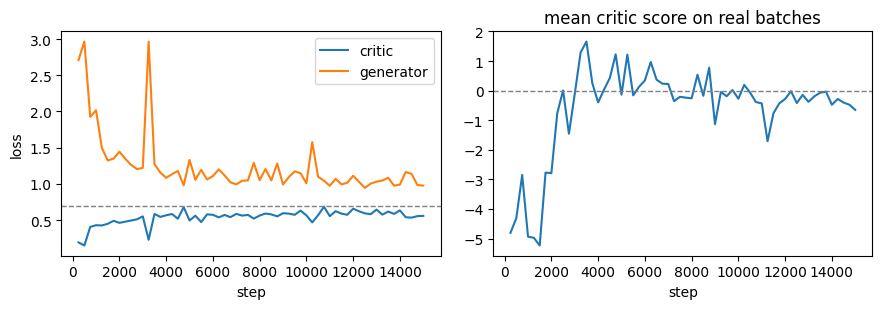

In [8]:
fig, axes = d2l.plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(history[:, 0], history[:, 1], label='critic')
axes[0].plot(history[:, 0], history[:, 2], label='generator')
axes[0].axhline(0.693, ls='--', c='gray', lw=1)
axes[0].set_xlabel('step'), axes[0].set_ylabel('loss'), axes[0].legend()
axes[1].plot(history[:, 0], history[:, 4])
axes[1].axhline(0, ls='--', c='gray', lw=1)
axes[1].set_xlabel('step')
axes[1].set_title('mean critic score on real batches')
fig.tight_layout()

The traces remain bounded throughout training. The dashed line marks $\log 2 \approx 0.693$, the value of both pairing losses when the critic cannot distinguish the two orderings of a pair. The critic loss settles slightly below this value and the generator loss slightly above it, without a sustained trend in either trace. The runs are not smooth: each has a sharp generator-loss excursion during the first few thousand steps. One excursion is modest, while the other reaches several times the eventual loss level. Both return to their previous ranges within a few logging intervals. The penalties therefore permit transient excursions but prevent persistent growth in these runs.

After an initial transient, the critic's mean score on real batches settles into a narrow band. This contrasts with the unbounded climb of the unpenalized classic arm in that section. The band's absolute level is arbitrary because the pairing objective is invariant to shifts in critic scores.

The next grid tests generation on demand. Each row fixes one class, and each column uses a fresh latent code. As in that section, the generator has no tanh. The display and all evaluations below therefore clamp its raw output to $[-1, 1]$; the printed diagnostic shows that only a small fraction of pixel values are affected.

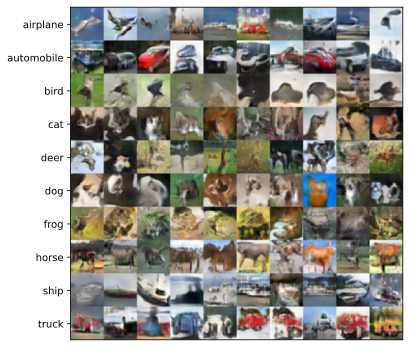

In [9]:
torch.manual_seed(42)
z = torch.randn(100, 100, device=device)
y = torch.arange(10, device=device).repeat_interleave(10)
with torch.no_grad():
    imgs = ((ema_G(z, y).clamp(-1, 1) + 1) / 2)
grid = imgs.reshape(10, 10, 3, 32, 32).permute(0, 3, 1, 4, 2)
grid = grid.reshape(320, 320, 3).cpu().numpy()
d2l.set_figsize((6, 6))
d2l.plt.imshow(grid)
d2l.plt.yticks([32 * i + 16 for i in range(10)], classes)
d2l.plt.xticks([]);

Most rows are visually associated with their requested class, although the association varies in strength. In the recorded runs, the automobile, truck, and ship rows contain recognizable wheeled bodies or hulls on water. The airplane row varies more across runs. The animal rows rely more heavily on color and background than on detailed anatomy. Deer appear as tan forms on grass and horses retain a characteristic silhouette, while birds, cats, and dogs sometimes become similar brown shapes. Within each row, pose, color, and background vary across columns, so the grid does not reveal a loss of within-class diversity.

This limited training budget is sufficient to demonstrate conditioning, but not to produce photorealistic samples. The same general recipe reaches much higher quality when trained for four days on eight GPUs [@Huang.Gokaslan.Kuleshov.ea.2024]. Visual inspection also cannot measure how often a generated image is recognized as its requested class. The next section introduces a quantitative test.

## Measuring Condition Alignment

An unconditional metric cannot detect a mismatch between generated images and their assigned conditions. The cyclic label shift above is one example: it preserves the marginal image distribution while violating every requested label. We measure this failure with a classifier trained on CIFAR-10. Because generated images already have the native $32 \times 32$ resolution, the small convolutional classifier from that section is trained at that resolution until its test accuracy plateaus.

For each generated image, the classifier either predicts the requested class or it does not. The matching fraction, computed both overall and per class, is the *condition alignment*. We compare this quantity with the classifier's accuracy on real test images from the same class. This reference matters because the classifier also misclassifies real examples. It is not an upper bound: unusually prototypical generated images can be easier to classify than real photographs.

In [10]:
class FeatureCNN(nn.Module):
    """Three conv blocks, global average pooling, and a linear head."""
    def __init__(self, feature_dim=128):
        super().__init__()
        widths = [3, 32, 64, feature_dim]
        self.blocks = nn.ModuleList(
            [nn.Sequential(nn.Conv2d(c_in, c_out, 3, padding=1),
                           nn.BatchNorm2d(c_out), nn.ReLU(),
                           nn.MaxPool2d(2))
             for c_in, c_out in zip(widths[:-1], widths[1:])])
        self.head = nn.Linear(feature_dim, 10)

    def features(self, x):
        for block in self.blocks:
            x = block(x)
        return x.mean(dim=(2, 3))

    def forward(self, x):
        return self.head(self.features(x))

torch.manual_seed(0)
cnn = FeatureCNN().to(device)
opt = torch.optim.Adam(cnn.parameters(), lr=0.001)
for epoch in range(15):
    order = torch.randperm(len(train_X), device=device)
    for i in range(0, len(order) - 255, 256):
        idx = order[i:i + 256]
        l = F.cross_entropy(cnn(train_X[idx]), train_y[idx])
        opt.zero_grad(), l.backward(), opt.step()
cnn.eval()
with torch.no_grad():
    pred = torch.cat([cnn(test_X[i:i + 1000]).argmax(1)
                      for i in range(0, len(test_X), 1000)])
cls_acc = [float((pred[test_y == c] == c).float().mean())
           for c in range(10)]
print(f'CIFAR-10 test accuracy: {float((pred == test_y).float().mean()):.3f}')

CIFAR-10 test accuracy: 0.711


In [11]:
torch.manual_seed(7)
align = []
for c in range(10):
    z = torch.randn(500, 100, device=device)
    yc = torch.full((500,), c, device=device)
    with torch.no_grad():
        pred_c = cnn(ema_G(z, yc).clamp(-1, 1)).argmax(1)
    align.append(float((pred_c == c).float().mean()))
print(f'{"class":12s}{"alignment":>11s}{"classifier":>12s}')
for c in range(10):
    print(f'{classes[c]:12s}{align[c]:11.2f}{cls_acc[c]:12.2f}')
print(f'{"overall":12s}{np.mean(align):11.2f}{np.mean(cls_acc):12.2f}')

class         alignment  classifier
airplane           0.73        0.81
automobile         0.73        0.84
bird               0.39        0.49
cat                0.28        0.38
deer               0.80        0.86
dog                0.47        0.58
frog               0.80        0.85
horse              0.69        0.81
ship               0.54        0.64
truck              0.78        0.84
overall            0.62        0.71


In each recorded framework run, overall alignment is within a few percentage points of the classifier's accuracy on real test images. The per-class results are less consistent. PyTorch and JAX identify different weak classes, with discrepancies larger than the counting noise expected from 500 samples per class. The two tabs therefore illustrate the measurement but do not establish a shared classwise pattern. The weakest generated rows also score below their visual impression. In the PyTorch run, the cat alignment is about ten points below the classifier's already modest accuracy on real cats; the JAX run shows a similar gap for dogs. In both cases, the classifier's weakest real class is also the generator's weakest measured class.

The difference between alignment and real-image accuracy may be positive or negative. The classifier's real-image accuracy does not cap the alignment score: generated samples that resemble class prototypes can exceed it, as the collapse baseline below demonstrates. In the recorded runs, every generated class remains below its corresponding real-image reference.

This comparison is not a calibration. The classifier is evaluated under distribution shift, so its errors on generated and real images need not have the same causes. A zero difference may combine compensating errors, and a positive difference may indicate prototypical artifacts rather than correct conditioning. The real-image reference gives the alignment score useful context, but the result remains a proxy. A stronger classifier may improve the proxy without changing the property it measures.

Condition alignment does not measure image quality. We therefore also compute the feature-distribution metrics from that section: the Fréchet distance in the equation and the unbiased $\mathrm{MMD}^2$ estimator in the equation. Because both use the features of the classifier trained here rather than Inception features, the table labels them `FD (CIFAR-CNN)` and `MMD^2 (CIFAR-CNN)`.

The evaluation compares 1,000 generated images, 100 per class, with 1,000 held-out test images selected in the same proportions. Thus the real and generated sets have identical balanced class marginals. A second disjoint and stratified set of 1,000 real images provides the finite-sample reference. As in that section, the final column reports the fraction of raw generated pixels outside $[-1,1]$.

In [12]:
def fid_score(feat_p, feat_q):
    feat_p, feat_q = np.float64(feat_p), np.float64(feat_q)
    mu_p, mu_q = feat_p.mean(0), feat_q.mean(0)
    C_p = np.cov(feat_p, rowvar=False)
    C_q = np.cov(feat_q, rowvar=False)
    lam, U = np.linalg.eigh(C_p)
    sqrt_C_p = (U * np.sqrt(np.maximum(lam, 0))) @ U.T
    M = sqrt_C_p @ C_q @ sqrt_C_p
    cross = np.linalg.eigvalsh((M + M.T) / 2)   # symmetric up to rounding
    return (((mu_p - mu_q) ** 2).sum() + np.trace(C_p) + np.trace(C_q)
            - 2 * np.sqrt(np.maximum(cross, 0)).sum())

def kid_score(feat_p, feat_q):
    m, n, d = len(feat_p), len(feat_q), feat_p.shape[1]
    K_pp = (feat_p @ feat_p.T / d + 1) ** 3
    K_qq = (feat_q @ feat_q.T / d + 1) ** 3
    K_pq = (feat_p @ feat_q.T / d + 1) ** 3
    return ((K_pp.sum() - np.trace(K_pp)) / (m * (m - 1))
            + (K_qq.sum() - np.trace(K_qq)) / (n * (n - 1))
            - 2 * K_pq.mean())

In [13]:
def features(imgs, bs=500):
    with torch.no_grad():
        return np.concatenate([cnn.features(imgs[i:i + bs]).cpu().numpy()
                               for i in range(0, len(imgs), bs)])

torch.manual_seed(11)
z = torch.randn(1000, 100, device=device)
yg = torch.arange(10, device=device).repeat_interleave(100)
with torch.no_grad():
    raw = ema_G(z, yg)
oob = float(((raw < -1) | (raw > 1)).float().mean())
gen = raw.clamp(-1, 1)
idx = [(test_y == c).nonzero().flatten()[:200] for c in range(10)]
f_real = features(test_X[torch.cat([i[:100] for i in idx])])
f_real2 = features(test_X[torch.cat([i[100:] for i in idx])])
f_gen = features(gen)
print(f'{"comparison":22s}{"FD (CIFAR-CNN)":>16s}{"MMD^2 (CIFAR-CNN)":>19s}'
      f'{"out-of-range":>14s}')
print(f'{"real vs. real":22s}{fid_score(f_real2, f_real):16.2f}'
      f'{kid_score(f_real2, f_real):19.3f}{"--":>14s}')
print(f'{"generated vs. real":22s}{fid_score(f_gen, f_real):16.2f}'
      f'{kid_score(f_gen, f_real):19.3f}{oob:14.3f}')

comparison              FD (CIFAR-CNN)  MMD^2 (CIFAR-CNN)  out-of-range
real vs. real                     0.72             -0.008            --
generated vs. real                1.56              0.052         0.005


The two distances support the visual assessment at different scales. In the recorded runs, generated-versus-real FD is a small multiple of the real-versus-real reference. The gap is measurable but much smaller than for the collapsed classic arm in that section, whose FD was two orders of magnitude above its reference. The unbiased $\mathrm{MMD}^2$ estimate gives the same ordering on a smaller numerical scale: the real-versus-real estimate fluctuates around zero, while the generated-versus-real estimate is small and positive.

These values depend on the chapter's feature network and cannot be compared with published FID or KID scores. They also measure only the *marginal feature-distribution fit*. Each combines fidelity and coverage in one number and ignores the labels. In this feature space, the generated marginal is nevertheless close to the real marginal. The alignment scores therefore do not come at the cost of a large loss in measured image quality.

Two established metrics combine sample quality with conditional information. The Fréchet joint distance embeds the image and condition together, so assigning a realistic image to the wrong condition changes the score even when marginal FD remains fixed [@DeVries.Romero.Pineda.ea.2019]. The classification accuracy score trains a classifier on labeled generated data and evaluates it on real data; missing or collapsed classes then appear as errors on real examples from those classes [@Ravuri.Vinyals.2019]. Both generalize the diagnostics constructed here from the chapter's classifier.

Three inexpensive checks connect the measurements to the preceding analysis. First, we keep the same 1,000 generated images and cyclically shift their *requested* labels. Alignment decreases because the images were generated for different labels, while pooled FD and $\mathrm{MMD}^2$ remain unchanged because neither metric receives a label. This is the counterexample from the opening of the section.

Second, we evaluate real images under their correct labels and under cyclically shifted labels. The difference in mean critic score cancels the unconditional head $\psi$ and the arbitrary score offset, leaving the contribution of the class embeddings. A positive value indicates that the projection head assigns higher compatibility to the correct condition.

Third, we construct a degenerate generator by repeating one fixed held-out image from each class 100 times. The classifier assigns these real images their labels often enough to produce high alignment, but the per-class feature variance is nearly zero. Feature variance, unlike alignment, directly detects this within-class collapse.

In [14]:
y_perm = (yg + 1) % 10
with torch.no_grad():
    pred_gen = cnn(gen).argmax(1)
    d_true = net_D(test_X[:1000], test_y[:1000]).mean()
    d_perm = net_D(test_X[:1000], (test_y[:1000] + 1) % 10).mean()
x0 = torch.stack([test_X[test_y == c][0] for c in range(10)])
fixed = x0.repeat_interleave(100, dim=0)
with torch.no_grad():
    pred_fix = cnn(fixed).argmax(1)
f_fix = features(fixed)
cvar = lambda f: float(np.float64(f).reshape(10, 100, -1).var(1).mean())
print(f'permuted labels: alignment '
      f'{float((pred_gen == yg).float().mean()):.2f} -> '
      f'{float((pred_gen == y_perm).float().mean()):.2f}, '
      f'FD {fid_score(f_gen, f_real):.2f}, '
      f'MMD^2 {kid_score(f_gen, f_real):.3f} (both unchanged)')
print(f'critic label check: mean D(x, y) - D(x, y+1) on real = '
      f'{float(d_true - d_perm):.2f}')
print(f'collapse baseline: alignment '
      f'{float((pred_fix == yg).float().mean()):.2f}, per-class feature '
      f'variance {cvar(f_fix):.3g} (generator {cvar(f_gen):.3g}, '
      f'real {cvar(f_real):.3g})')

permuted labels: alignment 0.60 -> 0.06, FD 1.56, MMD^2 0.052 (both unchanged)
critic label check: mean D(x, y) - D(x, y+1) on real = 0.13
collapse baseline: alignment 0.80, per-class feature variance 0 (generator 0.188, real 0.218)


Conditional evaluation has three distinct axes: sample fidelity, sample diversity, and condition alignment. None of the preceding metrics reports all three separately. The feature distances measure marginal fit and combine fidelity with coverage, whereas alignment measures only agreement with the requested condition.

The repeated-image baseline exposes this limitation. One stored image per class can attain alignment near the real-image reference despite having zero within-class diversity. This *within-class collapse* is mode collapse within a conditional distribution. The objective in the equation penalizes it because a point mass differs from $p(\cdot \mid c)$ under the divergences considered here. Alignment cannot detect the collapse, and a marginal feature distance observes it only after mixing the classes. Per-class feature variance provides a more direct diagnostic.

Incorrect labels are not the only conditional failure. A generator may ignore the condition, obey it through shortcuts such as background or palette, collapse within a condition, leak between conditions, neglect rare conditions, or optimize for classifier prototypes. A sound evaluation therefore considers fidelity, diversity, and alignment together. Exercise 4 extends the collapse diagnosis to per-class distribution metrics. Exercise 5 uses the same instruments to measure the truncation trick of @Brock.Donahue.Simonyan.2019, which deliberately exchanges diversity for alignment.

## Translation as Conditioning

The condition in the equation may be an entire image, such as a semantic map, edge sketch, or grayscale photograph. This gives *paired image-to-image translation*. Pix2pix [@Isola.Zhu.Zhou.ea.2017] trains the conditional critic $D(x,c)$ on output--input pairs and adds an L1 reconstruction loss against the paired target. The two losses represent different aspects of the output. The source image largely determines low-frequency structure, which the pointwise L1 loss recovers. Ambiguous local textures are averaged by a pointwise loss and may appear blurred. A patch critic instead compares local texture statistics with those of real image patches and promotes sharper output. that section develops this capacity argument in detail.

Unpaired translation instead provides two image collections, such as horses and zebras, without paired examples. CycleGAN [@Zhu.Park.Isola.ea.2017] uses marginal rather than conditional critics. For the direction $G: X \to Y$, the critic distinguishes real targets $y$ from translations $G(x)$ but never receives the source $x$. A second game handles the reverse direction. The two generators are coupled by a *cycle-consistency* loss that requires translation forward and back to approximately reconstruct the input. This reconstruction term constrains an otherwise underidentified mapping, but it does not guarantee the intended semantic correspondence. Two mappings may satisfy both cycles while pairing images in an unintended way. The table summarizes the distinction:

| | Critic sees the source? | Paired targets? | What carries the input--output relation |
|:--|:--|:--|:--|
| pix2pix | yes: $D(x, c)$ scores output--input pairs | yes | the conditional adversarial loss and the L1 term |
| CycleGAN | no: each critic scores its target marginal | no | the cycle-consistency loss alone |

Only pix2pix plays this section's conditional game; CycleGAN substitutes a reconstruction constraint for a conditional critic. The systems themselves, with their encoder-decoder generators and patch critics, are built in that section.

## Summary

Conditional generation trains on pairs $(x,c)$ and gives the condition to both networks. When real and generated pairs share the same marginal $p(c)$, the optimal critic is the conditional log density ratio $\log[p(x\mid c)/q(x\mid c)]$. The value is the average $E_c[2\,\mathrm{JS}(p(\cdot\mid c),q(\cdot\mid c))]-2\log2$. Saturation, non-saturating weights, relativistic pairing, and zero-centered penalties therefore apply separately within each condition. A label-shifted generator shows why this target is stronger than matching the unconditional marginal.

Conditions can enter through concatenation, condition-dependent modulation, or a compatibility head. Under a shared log-linear representation of the real and generated class posteriors, the Bayes decomposition gives the projection critic $D(x,c)=e_c^\top\varphi(x)+\psi(x)$. The CIFAR-10 experiment uses concatenation in the generator and this projection head in the critic. Within 15,000 steps, most requested classes produce visibly distinct rows, overall classifier alignment is close to the classifier's accuracy on real data, and the pooled feature distances remain near their real-versus-real references. The weakest classes differ between the recorded PyTorch and JAX runs, so classwise conclusions are specific to each run.

Conditional evaluation adds an axis that marginal sample metrics cannot observe. The pooled feature distances combine fidelity and coverage and ignore labels. Classifier alignment measures whether generated images match their requested labels, but it is an uncalibrated proxy because the classifier is itself evaluated under distribution shift. High alignment can coexist with within-class collapse, as the repeated-image baseline demonstrates; per-class variance or distributional metrics are needed to detect that failure. With an image as the condition, pix2pix uses a conditional critic on source--output pairs together with an L1 reconstruction term. CycleGAN instead uses marginal critics and places the input--output constraint in its cycle-consistency loss, which does not guarantee the intended semantic correspondence.

## Exercises

1. The projection derivation modeled both class posteriors as softmax classifiers over a *shared* feature map $\varphi$. Suppose instead that the two posteriors require different feature maps, $p(c \mid x) \propto \exp(u_c^\top \varphi_p(x))$ and $q(c \mid x) \propto \exp(w_c^\top \varphi_q(x))$ with $\varphi_p \neq \varphi_q$. What form does the critic take in place of the equation? Can this two-map critic be written as a single projection head over the concatenated feature map $(\varphi_p(x), \varphi_q(x))$? What does the answer say about whether the shared-map assumption is a limit on capacity or a constraint on structure, and about when a learned $\varphi$ can absorb it?
1. Verify the decomposition the equation numerically on a toy with known densities. Let $c \in \{1, 2\}$ with equal probability, $p(\cdot \mid 1) = \mathcal{N}(-2, 1)$, $p(\cdot \mid 2) = \mathcal{N}(2, 1)$, and let the generator be right on one slice and wrong on the other: $q(\cdot \mid 1) = \mathcal{N}(0, 1)$, $q(\cdot \mid 2) = \mathcal{N}(2, 1)$. Compute $E_c[2\,\mathrm{JS}] - 2\log 2$ by numerical integration on a grid. Then train a small critic that takes $(x, c)$, with $c$ one-hot, on samples from the two joints, taking the critic loss as the balanced mean of the real and fake cross-entropy terms (the reduction under which the stated relation holds), and compare its converged per-sample loss with your integral, using the relation from that section that the discriminator's minimal per-sample loss is $\log 2 - \mathrm{JS}$, here with the divergence averaged over the two conditions. Confirm that the critic's scores on the matched slice $c = 2$ are near zero while the mismatched slice carries the whole value.
1. Suppose the label marginal is imbalanced: nine classes share probability $(1 - \epsilon)$ evenly and one rare class has $p(c_{\textrm{rare}}) = \epsilon$. The value the equation weights the rare slice's divergence by $\epsilon$, so a generator that serves it arbitrarily badly pays at most $2\epsilon \log 2$. Compare this *across-slice* weighting with the *within-slice* imbalance of that section's exercises, where unequal priors inside one game produced the divergence $\alpha\, \mathrm{KL}(p \,\|\, m_\alpha) + (1-\alpha)\, \mathrm{KL}(q \,\|\, m_\alpha)$, which we may call an $\alpha$-skewed Jensen--Shannon divergence: which mechanism affects the optimal critic, and which only the value? Predict what happens to the rare class's condition alignment if CIFAR-10 is subsampled so one class is a hundred times rarer; if you have the compute, test the prediction with the code of this section, and a lighter test fits a small budget: keep two classes, subsample one to a few percent of the other, and train at the 4,000-step pilot budget. In either setting compare two remedies: drawing generator conditions from the natural, imbalanced label marginal, versus drawing them uniformly while re-weighting or re-sampling the real batches to match --- the prior-ratio correction from the shared-marginal caveat above.
1. The diagnostics cell detects within-class collapse through per-class feature variance. Extend the diagnosis to per-class distribution metrics: for each class $c$, embed $n$ generated and $n$ real samples of that class with the feature CNN and compute the per-class $\widehat{\mathrm{MMD}}^2$ of the equation, or per-class precision and recall. Score the trained generator of this section, rank the ten classes by within-class distance, and compare that ranking with the alignment table's: which classes are well aligned yet poorly distributed, or the reverse, and what do their samples look like?
1. BigGAN's truncation trick [@Brock.Donahue.Simonyan.2019] draws each latent coordinate from a standard Gaussian truncated to $[-\tau, \tau]$, resampling any coordinate that falls outside; in BigGAN this traded diversity for fidelity, a result that depended on that model's training setup. Implement truncation for the trained generator and sweep $\tau \in \{0.5, 1, 2\} \cup \{\infty\}$, where $\tau = \infty$ recovers ordinary sampling, reporting condition alignment and per-class feature variance for each $\tau$. Does alignment rise and within-class variance fall as $\tau$ shrinks here? A flat or reversed outcome for this small generator is a valid finding; report it and explain what it implies about how this generator uses the latent space away from the prior's mode.
1. Implement the concatenation critic: one-hot encode the label, broadcast it spatially, and append it to the critic's input as ten extra planes (or to an intermediate feature map), leaving the backbone otherwise unchanged. Retrain the game with this critic at a reduced budget of 4,000 steps, retrain the projection version at the same budget, and compare condition alignment and the feature-space distances. The comparison is a diagnostic of what the projection structure provides at a matched small budget, not a quality contest, and either ordering is a reportable result.
1. For pix2pix and for CycleGAN, list every adversarial loss in the system and classify its critic as conditional (it sees the source alongside the candidate output) or marginal (it sees only samples from the target collection). State, for each system, what carries the input--output relation, and explain how a CycleGAN whose cycle losses are near zero can still pair images in unintended ways.

[Discussions](https://d2l.discourse.group/)